
# PyTorch implementation of RISE Paper :
* Random mask generation with upsampling and random shifts

* Black-box mask probing → weighted aggregation → saliency map

* Deletion metric

* Insertion metric

* Pointing game accuracy evaluation (if ground truth masks are provided)

* Visualization of saliency maps


In [4]:
# === Imports ===
import torch
import torch.nn.functional as F
import torchvision.transforms as T
from torchvision.models import resnet50
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import random
from torchvision.models import resnet50
import os

# === Utility Functions ===

def load_image(path, image_size=224):
    transform = T.Compose([
        T.Resize((image_size, image_size)),
        T.ToTensor(),
        T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
    ])
    img = Image.open(path).convert('RGB')
    return transform(img).unsqueeze(0)

# === RISE Mask Generation ===
def generate_random_masks(N, H, W, h=7, w=7, p=0.5):
    """
    Generate N random masks with:
    1. Small binary masks of size h x w
    2. Upsampled to H x W via bilinear interpolation
    3. Random shift in both axes
    """
    small_masks = np.random.choice([0,1], size=(N,1,h,w), p=[1-p, p])
    masks = torch.tensor(small_masks, dtype=torch.float32)
    masks = F.interpolate(masks, size=(H+H//h, W+W//w), mode='bilinear', align_corners=False)

    # Random crop shift
    cropped_masks = torch.zeros((N,1,H,W))
    for i in range(N):
        max_x_shift = masks.shape[3] - W
        max_y_shift = masks.shape[2] - H
        x_shift = random.randint(0, max_x_shift)
        y_shift = random.randint(0, max_y_shift)
        cropped_masks[i,0] = masks[i,0, y_shift:y_shift+H, x_shift:x_shift+W]
    return cropped_masks

# === RISE Saliency Computation ===
def rise(model, image, N=8000, h=7, w=7, p=0.5, device='cuda'):
    """
    Compute RISE saliency map for a black-box model
    """
    model.eval()
    image = image.to(device)
    _,C,H,W = image.shape

    # Step 1: Generate masks
    masks = generate_random_masks(N,H,W,h,w,p).to(device)

    # Step 2: Apply masks
    masked_images = image * masks

    # Step 3: Forward pass
    with torch.no_grad():
        outputs = model(masked_images)
        probs = F.softmax(outputs, dim=1)

    # Step 4: Top predicted class
    with torch.no_grad():
        orig_out = model(image)
        top_class = torch.argmax(F.softmax(orig_out,dim=1), dim=1).item()

    # Step 5: Weighted sum of masks
    saliency = torch.sum(masks.squeeze(1) * probs[:,top_class].view(-1,1,1), dim=0)
    saliency /= N * p

    return saliency.cpu().numpy(), top_class

# === Deletion Metric ===
def deletion_metric(model, image, saliency, top_class, steps=50, device='cuda'):
    """
    Gradually remove most salient pixels and track probability drop
    """
    model.eval()
    image = image.to(device)
    prob_curve = []

    # Flatten saliency and sort indices
    sal_flat = saliency.flatten()
    indices = np.argsort(-sal_flat)  # descending order

    # Copy image
    img_copy = image.clone()
    num_pixels = sal_flat.shape[0]
    step_pixels = num_pixels // steps

    with torch.no_grad():
        for i in range(steps):
            start = i*step_pixels
            end = (i+1)*step_pixels
            idx = indices[start:end]
            # Convert flat index to 2D
            ys, xs = np.unravel_index(idx, saliency.shape)
            img_copy[0,:,ys,xs] = 0  # set to zero
            out = model(img_copy)
            prob = F.softmax(out,dim=1)[0,top_class].item()
            prob_curve.append(prob)
    auc = np.trapz(prob_curve) / steps
    return auc, prob_curve

# === Insertion Metric ===
def insertion_metric(model, image, saliency, top_class, steps=50, device='cuda'):
    """
    Gradually add pixels according to saliency starting from blurred image
    """
    from torchvision.transforms import GaussianBlur
    model.eval()
    image = image.to(device)
    prob_curve = []

    # Create blurred canvas
    blur = T.GaussianBlur(kernel_size=11, sigma=5)
    blurred_img = blur(image)
    img_copy = blurred_img.clone()

    # Flatten saliency and sort indices
    sal_flat = saliency.flatten()
    indices = np.argsort(-sal_flat)  # descending order

    num_pixels = sal_flat.shape[0]
    step_pixels = num_pixels // steps

    with torch.no_grad():
        for i in range(steps):
            start = i*step_pixels
            end = (i+1)*step_pixels
            idx = indices[start:end]
            ys, xs = np.unravel_index(idx, saliency.shape)
            img_copy[0,:,ys,xs] = image[0,:,ys,xs]  # reveal original pixels
            out = model(img_copy)
            prob = F.softmax(out,dim=1)[0,top_class].item()
            prob_curve.append(prob)
    auc = np.trapz(prob_curve) / steps
    return auc, prob_curve

# === Visualization ===
def visualize_saliency(image_path, saliency):
    img = Image.open(image_path).convert('RGB').resize((224,224))
    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1)
    plt.imshow(img)
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(img)
    plt.imshow(saliency, cmap='jet', alpha=0.5)
    plt.title("RISE Saliency Map")
    plt.axis('off')
    plt.show()


In [5]:
import os
import random
import requests
from zipfile import ZipFile
from shutil import copyfile
import json

# -------------------------------
# Parameters
# -------------------------------
NUM_IMAGES = 100  # Number of images to sample since the all the set is too large
DATA_DIR = "coco_subset"
VAL_IMAGES_DIR = os.path.join(DATA_DIR, "val2017")
SAMPLED_DIR = os.path.join(DATA_DIR, "sample_val2017")
ANNOTATIONS_URL = "http://images.cocodataset.org/annotations/annotations_trainval2017.zip"
VAL_IMAGES_URL = "http://images.cocodataset.org/zips/val2017.zip"

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(SAMPLED_DIR, exist_ok=True)

# -------------------------------
# Helper: download file
# -------------------------------
def download_file(url, save_path):
    if os.path.exists(save_path):
        print(f"{save_path} already exists. Skipping download.")
        return
    print(f"Downloading {url} ...")
    r = requests.get(url, stream=True)
    with open(save_path, 'wb') as f:
        for chunk in r.iter_content(chunk_size=1024*1024):
            if chunk:
                f.write(chunk)
    print(f"Saved to {save_path}")

# -------------------------------
# Step 1: Download COCO val2017 images (if not already)
# -------------------------------
val_zip_path = os.path.join(DATA_DIR, "val2017.zip")
download_file(VAL_IMAGES_URL, val_zip_path)

# -------------------------------
# Step 2: Unzip val2017 images
# -------------------------------
if not os.path.exists(VAL_IMAGES_DIR):
    print("Extracting val2017 images ...")
    with ZipFile(val_zip_path, 'r') as zip_ref:
        zip_ref.extractall(DATA_DIR)
    print("Extraction done.")

# -------------------------------
# Step 3: Download annotations (optional)
# -------------------------------
annotations_zip_path = os.path.join(DATA_DIR, "annotations.zip")
download_file(ANNOTATIONS_URL, annotations_zip_path)

annotations_dir = os.path.join(DATA_DIR, "annotations")
if not os.path.exists(annotations_dir):
    print("Extracting annotations ...")
    with ZipFile(annotations_zip_path, 'r') as zip_ref:
        zip_ref.extractall(DATA_DIR)
    print("Annotations extracted.")

# -------------------------------
# Step 4: Load annotations and sample images
# -------------------------------
val_annotations_file = os.path.join(annotations_dir, "instances_val2017.json")
with open(val_annotations_file) as f:
    coco = json.load(f)

# Get all image filenames
image_filenames = [img['file_name'] for img in coco['images']]
sampled_images = random.sample(image_filenames, NUM_IMAGES)

# Copy sampled images to new folder
for img_name in sampled_images:
    src = os.path.join(VAL_IMAGES_DIR, img_name)
    dst = os.path.join(SAMPLED_DIR, img_name)
    copyfile(src, dst)

print(f"Sampled {NUM_IMAGES} images saved in '{SAMPLED_DIR}'")


Saved to coco_subset/val2017.zip
Extracting val2017 images ...
Extraction done.
Saved to coco_subset/annotations.zip
Extracting annotations ...
Annotations extracted.
Sampled 100 images saved in 'coco_subset/sample_val2017'


Predicted class: 874
Deletion AUC: 0.009269249935309318
Insertion AUC: 0.6184900902904338


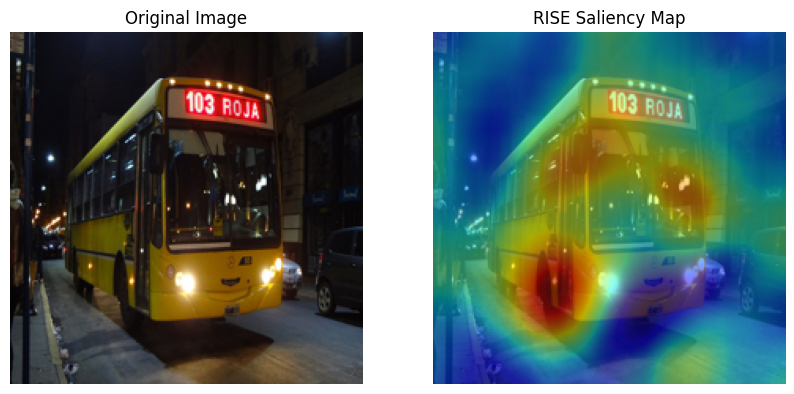

In [24]:

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = resnet50(pretrained=True).to(device)

sampled_dir = "coco_subset/sample_val2017"
image_paths = [os.path.join(sampled_dir, f) for f in os.listdir(sampled_dir) if f.endswith('.jpg')]

def load_image(path, image_size=224):
    transform = T.Compose([
        T.Resize((image_size, image_size)),
        T.ToTensor(),
        T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
    ])
    img = Image.open(path).convert('RGB')
    return transform(img).unsqueeze(0)

# Example for first image
image = load_image(image_paths[0])
saliency, pred_class = rise(model, image, N=1000, h=7, w=7, p=0.5, device=device)
del_auc, del_curve = deletion_metric(model, image, saliency, pred_class, steps=50, device=device)
ins_auc, ins_curve = insertion_metric(model, image, saliency, pred_class, steps=50, device=device)

print("Predicted class:", pred_class)
print("Deletion AUC:", del_auc)
print("Insertion AUC:", ins_auc)

visualize_saliency(image_paths[0], saliency)

In [15]:
import pandas as pd
from tqdm import tqdm

# --- Set device ---
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# --- Load model ---
model = resnet50(pretrained=True).to(device)

# --- Paths ---
sampled_dir = "coco_subset/sample_val2017"
saliency_dir = "coco_subset/saliency_maps"
os.makedirs(saliency_dir, exist_ok=True)

# --- Image loader ---
def load_image(path, image_size=224):
    transform = T.Compose([
        T.Resize((image_size, image_size)),
        T.ToTensor(),
        T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
    ])
    img = Image.open(path).convert('RGB')
    return transform(img).unsqueeze(0)

# --- Visualization function ---
def visualize_and_save(image_path, saliency, save_path):
    img = Image.open(image_path).convert('RGB').resize((224,224))
    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.imshow(saliency, cmap='jet', alpha=0.5)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(save_path)
    plt.close()

# --- RISE, deletion, insertion functions ---
# (Assume your previously defined functions rise, deletion_metric, insertion_metric are here)

# --- Metrics storage ---
metrics_list = []

# --- Loop through images ---
image_paths = [os.path.join(sampled_dir, f) for f in os.listdir(sampled_dir) if f.endswith('.jpg')]

for img_path in tqdm(image_paths, desc="Processing Images"):
    try:
        image = load_image(img_path).to(device)
        saliency, pred_class = rise(model, image, N=1000, h=7, w=7, p=0.5, device=device)

        del_auc, del_curve = deletion_metric(model, image, saliency, pred_class, steps=50, device=device)
        ins_auc, ins_curve = insertion_metric(model, image, saliency, pred_class, steps=50, device=device)

        # Save saliency map
        fname = os.path.basename(img_path).replace('.jpg','_saliency.png')
        save_path = os.path.join(saliency_dir, fname)
        visualize_and_save(img_path, saliency, save_path)

        # Record metrics
        metrics_list.append({
            "image": os.path.basename(img_path),
            "pred_class": pred_class,
            "deletion_auc": del_auc,
            "insertion_auc": ins_auc
        })

    except Exception as e:
        print(f"Error processing {img_path}: {e}")

# --- Save metrics to CSV ---
metrics_df = pd.DataFrame(metrics_list)
metrics_df.to_csv(os.path.join(saliency_dir, "metrics.csv"), index=False)

print("RISE saliency maps and metrics saved successfully.")


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Processing Images: 100%|██████████| 100/100 [04:48<00:00,  2.89s/it]

RISE saliency maps and metrics saved successfully.


In [17]:
# Load the metrics CSV
metrics_df = pd.read_csv(os.path.join(saliency_dir, "metrics.csv"))

# Display the first few rows
metrics_df.head()


,image,pred_class,deletion_auc,insertion_auc
0,000000269632.jpg,874,0.004628,0.607289
1,000000078266.jpg,744,0.012659,0.115206
2,000000365745.jpg,734,0.002702,0.215083
3,000000384136.jpg,589,0.069941,0.806583
4,000000146155.jpg,762,0.001549,0.403166


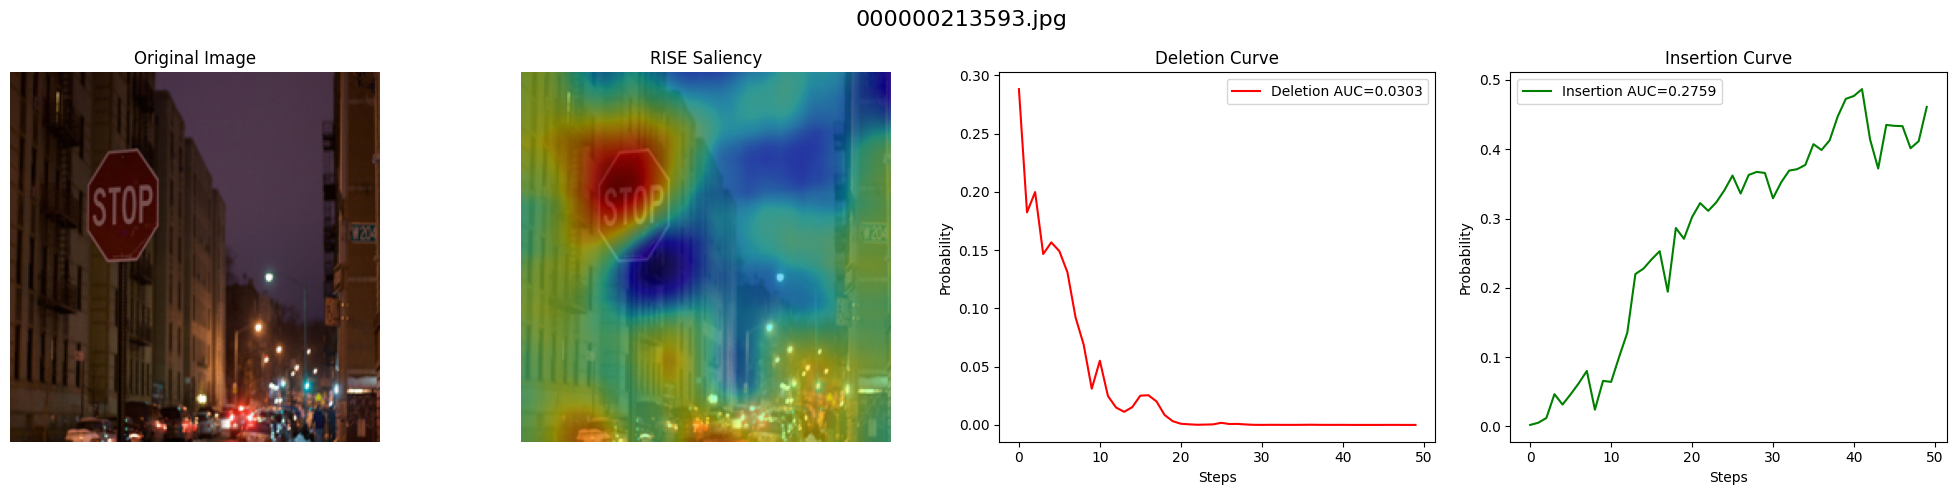

Image: 000000213593.jpg | Predicted class: 468
Deletion AUC: 0.0303 | Insertion AUC: 0.2759
------------------------------------------------------------


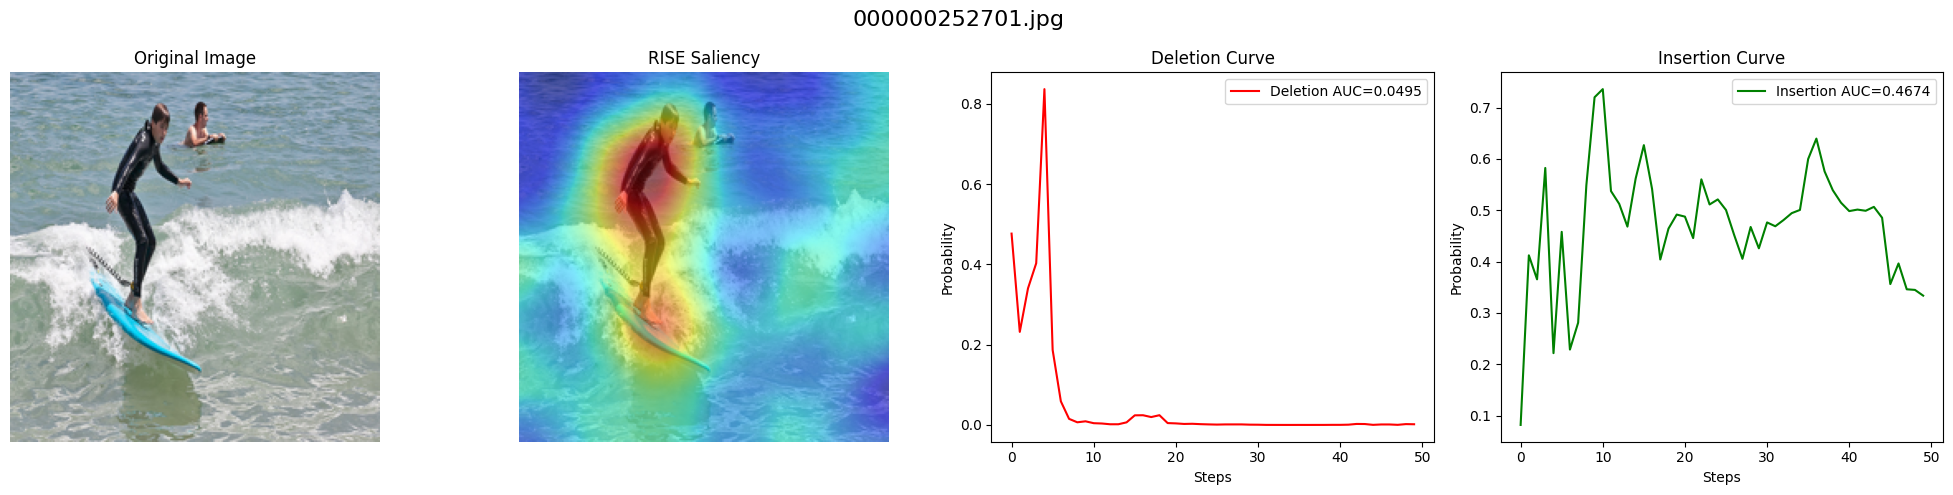

Image: 000000252701.jpg | Predicted class: 693
Deletion AUC: 0.0495 | Insertion AUC: 0.4674
------------------------------------------------------------


In [20]:
# RISE-generated importance maps for two representative images
two_images = random.sample(image_paths, 2)

for img_path in two_images:
    image = load_image(img_path).to(device)
    
    # Compute saliency
    saliency, pred_class = rise(model, image, N=1000, h=7, w=7, p=0.5, device=device)
    
    # Compute deletion & insertion metrics
    del_auc, del_curve = deletion_metric(model, image, saliency, pred_class, steps=50, device=device)
    ins_auc, ins_curve = insertion_metric(model, image, saliency, pred_class, steps=50, device=device)
    
    # Load original image
    orig_img = Image.open(img_path).convert('RGB').resize((224,224))
    
    # Create figure
    fig, axes = plt.subplots(1,4, figsize=(20,5))
    
    # Original image
    axes[0].imshow(orig_img)
    axes[0].set_title("Original Image")
    axes[0].axis('off')
    
    # RISE saliency map
    axes[1].imshow(orig_img)
    axes[1].imshow(saliency, cmap='jet', alpha=0.5)
    axes[1].set_title("RISE Saliency")
    axes[1].axis('off')
    
    # Deletion curve
    axes[2].plot(range(len(del_curve)), del_curve, color='red', label=f'Deletion AUC={del_auc:.4f}')
    axes[2].set_title("Deletion Curve")
    axes[2].set_xlabel("Steps")
    axes[2].set_ylabel("Probability")
    axes[2].legend()
    
    # Insertion curve
    axes[3].plot(range(len(ins_curve)), ins_curve, color='green', label=f'Insertion AUC={ins_auc:.4f}')
    axes[3].set_title("Insertion Curve")
    axes[3].set_xlabel("Steps")
    axes[3].set_ylabel("Probability")
    axes[3].legend()
    
    plt.suptitle(os.path.basename(img_path), fontsize=16)
    plt.tight_layout()
    plt.show()
    
    print(f"Image: {os.path.basename(img_path)} | Predicted class: {pred_class}")
    print(f"Deletion AUC: {del_auc:.4f} | Insertion AUC: {ins_auc:.4f}")
    print("-"*60)
